In [1]:
!pwd

/home/wenwen/jupyter/DataCenter/DataReader


In [1]:
import os
import pickle
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pycocotools import mask as coco_mask

# 如果需要连通域分析，可以使用 skimage
from skimage import measure, morphology

def rle_to_mask(rle):
    """
    将RLE字典转换为mask。
    rle: {'size': [height, width], 'counts': ...}
    """
    return coco_mask.decode(rle)


In [2]:
image_abs_path = "/mnt/user_data/wenwen/data/clevr/clevr_basic_100000/images/CLEVR_sample_000020.png"
edges_abs_path = "/mnt/shared/data/DINO_SAM2_Data/clevr/clevr_basic_100000/CLEVR_sample_000020_edges.pkl"

# 读取图像
image = Image.open(image_abs_path).convert("RGB")
image_np = np.array(image)

# 读取 pkl 文件中的 RLE 并转换为二值掩码
with open(edges_abs_path, 'rb') as f:
    combined_edges = pickle.load(f)
rle = {
    'size': combined_edges['size'],
    'counts': combined_edges['counts']
}
edge_mask = rle_to_mask(rle)  # 形状 (H, W)，0/1 二值


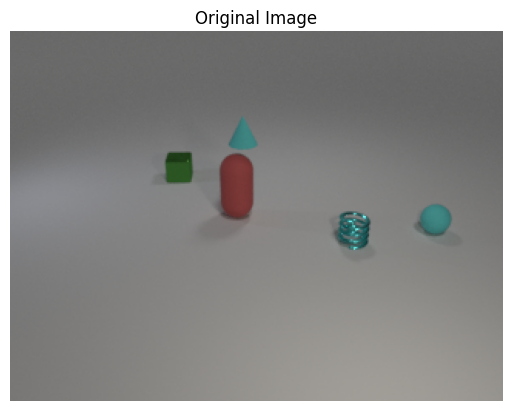

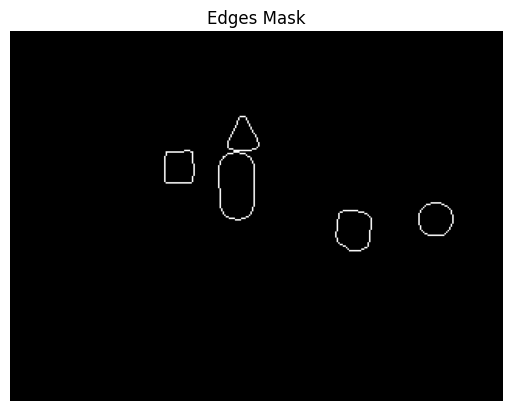

In [3]:
plt.figure()
plt.imshow(image_np) 
plt.title("Original Image") 
plt.axis('off') 
plt.show()

plt.figure() 
plt.imshow(edge_mask, cmap='gray') 
plt.title("Edges Mask") 
plt.axis('off') 
plt.show()

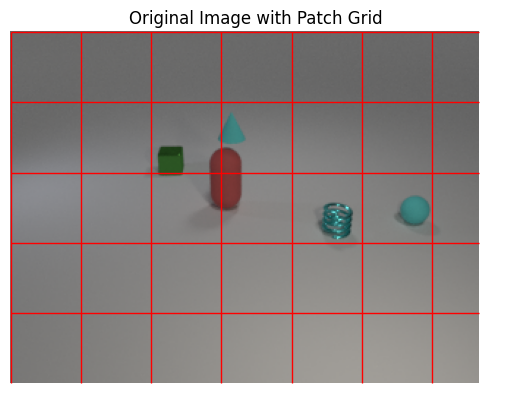

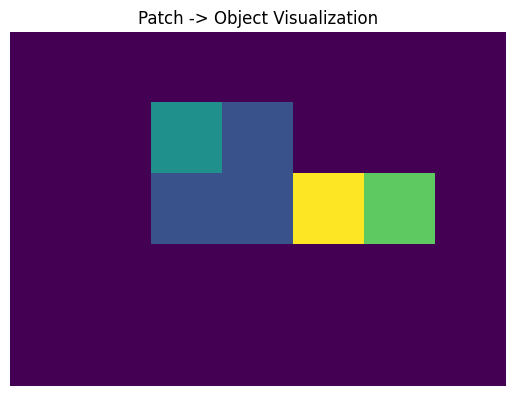

In [19]:
import os
import pickle
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from pycocotools import mask as coco_mask
from skimage.measure import label
from scipy.ndimage import binary_fill_holes

def rle_to_mask(rle):
    """
    将RLE字典转换为mask。
    rle: {'size': [height, width], 'counts': ...}
    """
    return coco_mask.decode(rle)

def load_edges_mask(edges_path):
    """
    读取 pkl 文件并返回一个 shape=(H, W) 的 0/1 矩阵。
    """
    with open(edges_path, 'rb') as f:
        combined_edges = pickle.load(f)
    # 构建RLE字典并解码得到 edges_mask
    rle = {
        'size': combined_edges['size'],
        'counts': combined_edges['counts']
    }
    edges_mask = rle_to_mask(rle)
    return edges_mask

def fill_edges_to_objects(edges_mask):
    """
    将只包含边缘的掩码（1 表示物体边缘）转换为物体区域。
    1) 先将 edges_mask > 0 转为 bool 类型
    2) 用 binary_fill_holes 填充内部区域
    3) 用 label 对各连通区域打 label ID
    返回：labels，其值为 0 表示背景，1,2,... 表示不同物体。
    """
    # edges_mask 可能是 (H, W) 的 0/1 矩阵
    bool_mask = edges_mask > 0
    # 填充物体内部
    filled_mask = binary_fill_holes(bool_mask)
    # 连通组件标记
    labels = label(filled_mask)
    return labels

def show_image_with_patches(image, patch_size):
    """
    显示原图，并且可视化网络分块（patch）的网格。
    """
    H, W = image.size[1], image.size[0]  # PIL 的 size 是 (width, height)
    
    plt.figure()
    plt.imshow(image)
    plt.title("Original Image with Patch Grid")
    plt.axis('off')
    
    # 画出网格线
    # 从上到下，每隔 patch_size 画一条横线
    for y in range(0, H, patch_size):
        plt.hlines(y, 0, W, linewidth=1, color='red')
    # 从左到右，每隔 patch_size 画一条竖线
    for x in range(0, W, patch_size):
        plt.vlines(x, 0, H, linewidth=1, color='red')
        
    plt.show()

def patch_to_object_mapping(labels, patch_size):
    """
    给定按 label 分好的物体区域，以及指定的 patch 大小，
    统计每个 patch 内哪个 label(对象)面积占比最大，
    返回一个 2D 数组 patch_map，形状是 (n_patch_row, n_patch_col)，
    其中每个元素是该 patch 最占主导的对象 ID。
    """
    H, W = labels.shape
    n_patch_row = (H + patch_size - 1) // patch_size
    n_patch_col = (W + patch_size - 1) // patch_size
    
    patch_map = np.zeros((n_patch_row, n_patch_col), dtype=int)
    
    for pr in range(n_patch_row):
        for pc in range(n_patch_col):
            # 每个 patch 的图像坐标范围
            y_start = pr * patch_size
            y_end   = min((pr+1)*patch_size, H)
            x_start = pc * patch_size
            x_end   = min((pc+1)*patch_size, W)
            
            patch_region = labels[y_start:y_end, x_start:x_end]
            if patch_region.size == 0:
                continue
            
            # 计算出现最多的 label
            # (不计算 label=0，因为那是背景)
            vals, counts = np.unique(patch_region, return_counts=True)
            # 去掉背景
            bg_idx = np.where(vals == 0)
            vals = np.delete(vals, bg_idx)
            counts = np.delete(counts, bg_idx)
            
            if len(vals) > 0:                
                dominant_label = vals[np.argmax(counts)]
            else:
                dominant_label = 0  # 如果patch里没有任何对象
                
            patch_map[pr, pc] = dominant_label
    
    return patch_map

def visualize_patch_map(patch_map):
    """
    可视化刚才得到的 patch_map。patch_map 中每个值都是对象 ID，
    我们可以直接用 imshow 显示，它会自动用不同的颜色对应不同的对象 ID。
    """
    plt.figure()
    plt.imshow(patch_map, interpolation='nearest')
    plt.title("Patch -> Object Visualization")
    plt.axis('off')
    plt.show()

# 下面演示完整流程
def demo_clip_style_partition(image_path, edges_path, patch_size=16):
    """
    演示：
      1. 读取图片
      2. 将图像分成 patch 并可视化
      3. 利用 edges 信息得到对象区域（labels）
      4. 计算每个 patch 所对应的对象 ID
      5. 可视化 patch -> 对象的映射结果
    """
    # 1. 读取图像
    image = Image.open(image_path).convert("RGB")
    # 2. 显示原图 + patch 网格
    show_image_with_patches(image, patch_size)

    # 3. 从 edges pkl 读取 edges_mask，并做 fill + 连通组件分析
    edges_mask = load_edges_mask(edges_path)
    labels = fill_edges_to_objects(edges_mask)

    # 4. 按照 patch_size，对 labels 做统计，得到 patch -> object
    patch_map = patch_to_object_mapping(labels, patch_size)
    
    # 5. 显示 patch_map
    visualize_patch_map(patch_map)

    return patch_map

# === 使用示例 ===
# 你可以修改下面的路径及 patch_size 自行测试
image_abs_path = "/mnt/user_data/wenwen/data/clevr/clevr_basic_100000/images/CLEVR_sample_000020.png"
edges_abs_path = "/mnt/shared/data/DINO_SAM2_Data/clevr/clevr_basic_100000/CLEVR_sample_000020_edges.pkl"

patch_map = demo_clip_style_partition(image_abs_path, edges_abs_path, patch_size=48)


In [10]:
import numpy as np
import torch

def generate_object_attention_mask(patch_map):
    """
    输入: patch_map, shape=(n_row, n_col)
    输出: attn_mask, shape=(n_patches, n_patches)，
          其中相同object的是0，不同object的是-∞（masked）
    """
    patch_map_flat = patch_map.flatten()  # (n_patches,)
    n_patches = patch_map_flat.shape[0]
    
    # 扩展成 (n_patches, 1) 和 (1, n_patches)，然后比较
    object_id_row = patch_map_flat[:, None]   # (n_patches, 1)
    object_id_col = patch_map_flat[None, :]   # (1, n_patches)
    
    # 比较是否相同，得到bool矩阵
    same_object = (object_id_row == object_id_col)  # (n_patches, n_patches)
    
    # 构造attention mask
    attn_mask = torch.where(
        same_object,
        torch.zeros_like(same_object, dtype=torch.float32),    # 相同object，mask 0（正常）
        torch.full_like(same_object, fill_value=-1e9, dtype=torch.float32)  # 不同object，mask为-∞
    )
    
    return attn_mask  # (n_patches, n_patches)


Patch Map:
[[0 0 0 0 0 0 0]
 [0 0 2 1 0 0 0]
 [0 0 1 1 4 3 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]


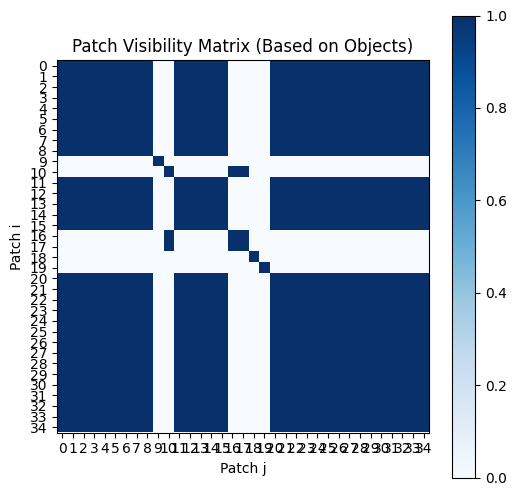

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def generate_object_attention_mask(patch_map):
    patch_map_flat = patch_map.flatten()  # (n_patches,)
    n_patches = patch_map_flat.shape[0]
    
    object_id_row = patch_map_flat[:, None]
    object_id_col = patch_map_flat[None, :]
    
    same_object = (object_id_row == object_id_col)
    
    return same_object.astype(np.float32)  # 1.0表示可以看见，0.0表示不能

def visualize_attention_mask(attn_mask, patch_map):
    plt.figure(figsize=(6,6))
    plt.imshow(attn_mask, cmap='Blues', interpolation='nearest')
    plt.colorbar()
    plt.title("Patch Visibility Matrix (Based on Objects)")
    plt.xticks(np.arange(attn_mask.shape[1]))
    plt.yticks(np.arange(attn_mask.shape[0]))
    plt.xlabel('Patch j')
    plt.ylabel('Patch i')
    plt.grid(False)
    
    # 显示 patch_map 原始信息
    print("Patch Map:")
    print(patch_map)

    plt.show()


attn_mask_example = generate_object_attention_mask(patch_map)
visualize_attention_mask(attn_mask_example, patch_map)
